# Center Surround Flicker Noise

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [3]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [4]:
pixel_size_um = 10

crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [5]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [6]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['BlueCS_5Hz_60Hz_10um_pixels.mp4',
 'BlueCS_5Hz_60Hz_10um_pixels.npz',
 'BlueCS_5Hz_60Hz_10um_pixels_mark.npz',
 'GreenCS_5Hz_60Hz_10um_pixels.mp4',
 'GreenCS_5Hz_60Hz_10um_pixels.npz',
 'GreenCS_5Hz_60Hz_10um_pixels_mark.npz']

In [7]:
green_name = 'green'
green_file = 'GreenCS_5Hz_60Hz_10um_pixels.npz'
green_mark_file = 'GreenCS_5Hz_60Hz_10um_pixels_mark.npz'

blue_name = 'blue'
blue_file = 'BlueCS_5Hz_60Hz_10um_pixels.npz'
blue_mark_file = 'BlueCS_5Hz_60Hz_10um_pixels_mark.npz'

In [8]:
# We downsample to reduce the size of the stimulus without losing any (!) information, since the frames are updated at 5 Hz.
target_freq = 5
source_freq = 60

t_downsample = int(source_freq/target_freq)  
t_downsample

12

## Green CS

In [9]:
green_mark = np.load(os.path.join(qdspy_export_dir, green_mark_file))['data']
green_mark = np.append(green_mark[:-1] & (~green_mark[1:]), False)
i0 = np.argmax(green_mark > 0)
green_mark = green_mark[i0::t_downsample]
green_mark.shape, np.sum(green_mark)

((1505,), np.int64(300))

In [10]:
green = np.load(os.path.join(qdspy_export_dir, green_file))['data']
green = green[i0::t_downsample, :, :]
green.shape

(1505, 120, 120, 3)

## Blue CS

In [11]:
blue_mark = np.load(os.path.join(qdspy_export_dir, blue_mark_file))['data']
blue_mark = np.append(blue_mark[:-1] & (~blue_mark[1:]), False)
i0 = np.argmax(blue_mark > 0)
blue_mark = blue_mark[i0::t_downsample]
blue_mark.shape, np.sum(blue_mark)

((1505,), np.int64(300))

In [12]:
blue = np.load(os.path.join(qdspy_export_dir, blue_file))['data']
blue = blue[i0::t_downsample, :, :]
blue.shape

(1505, 120, 120, 3)

## Compare

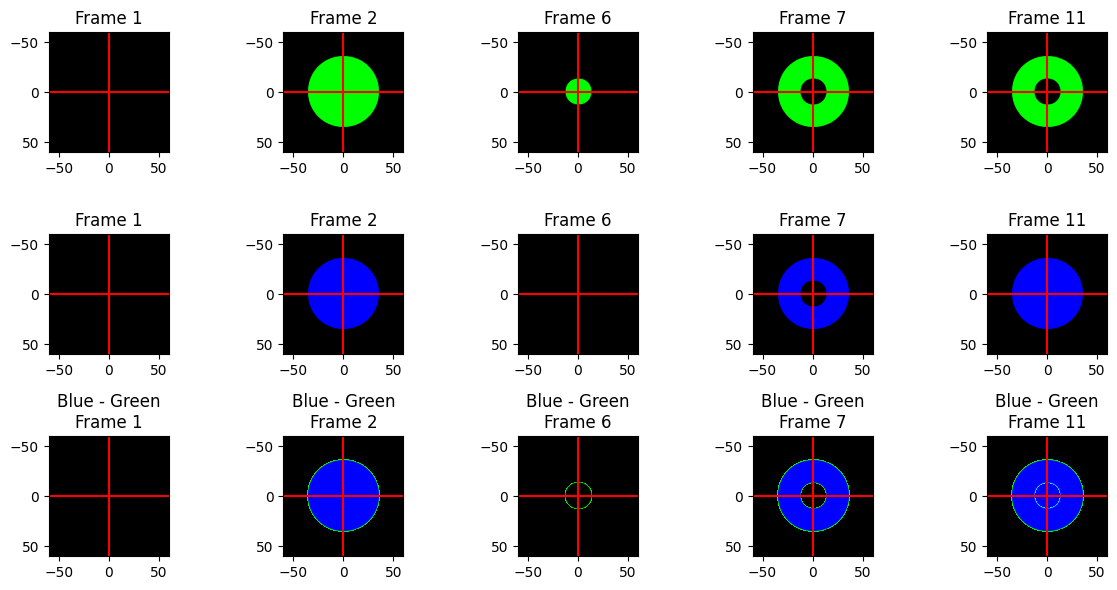

In [13]:
h, w = green.shape[1:3]
frames = [0, 1, 5, 6, 10]
fig, axs = plt.subplots(3, len(frames), figsize=(12, 6))

for j, frame in enumerate(frames):
    for i, stim in enumerate([green, blue]):
        axs[i, j].imshow(stim[frame], vmin=0, vmax=255, interpolation='none', cmap='gray', extent=(-w/2, w/2, h/2, -h/2))
        axs[i, j].axhline(0, color='r')
        axs[i, j].axvline(0, color='r')
        axs[i, j].set(title=f'Frame {frame + 1}')

    axs[2, j].imshow(blue[frame] - green[frame], vmin=-255, vmax=255, interpolation='none', cmap='coolwarm', extent=(-w/2, w/2, h/2, -h/2))
    axs[2, j].axhline(0, color='r')
    axs[2, j].axvline(0, color='r')
    axs[2, j].set(title=f'Blue - Green\nFrame {frame + 1}')
plt.tight_layout()
plt.show()

In [14]:
time_stim = np.arange(green.shape[0]) * t_downsample/60.

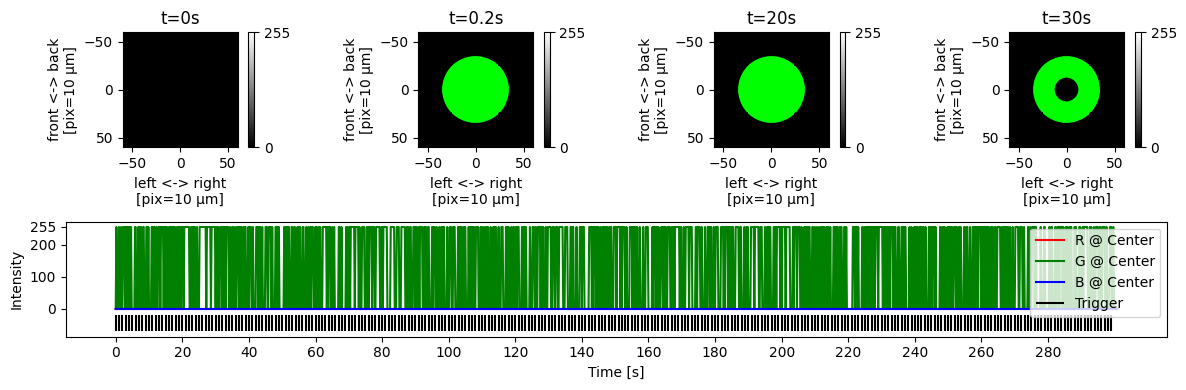

In [15]:
t_s_plot = (0, 1/5, 20, 30)

plot_stim(green, green_mark, time_stim, t_s_plot=t_s_plot);

In [16]:
noise_setup1 = np.flip(np.rot90(green, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
shifty_setup1 = np.flip(np.rot90(blue, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]

noise_setup3 = np.rot90(green, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
shifty_setup3 = np.rot90(blue, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [17]:
stim_dict =  {
    (green_name, '1'): noise_setup1,
    (blue_name, '1'): shifty_setup1,
    #(green_name, '3'): noise_setup3,
    #(blue_name, '3'): shifty_setup3,
}

Plotting green


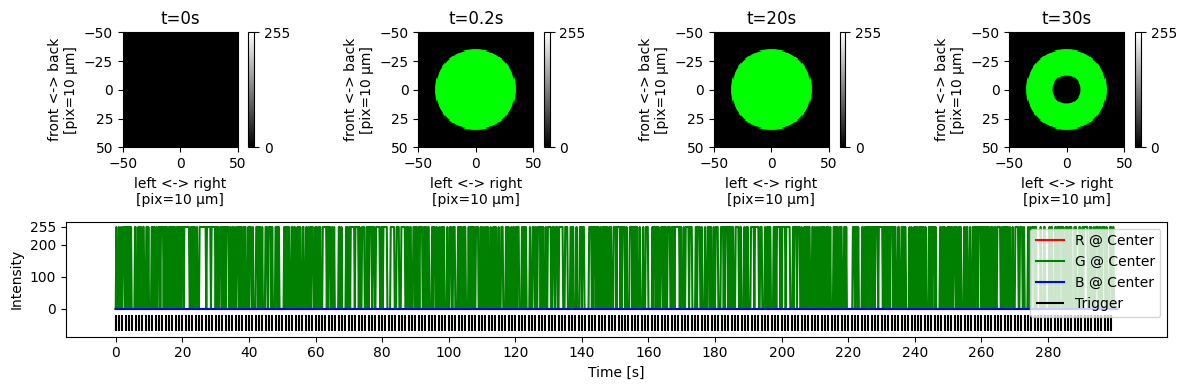

Plotting blue


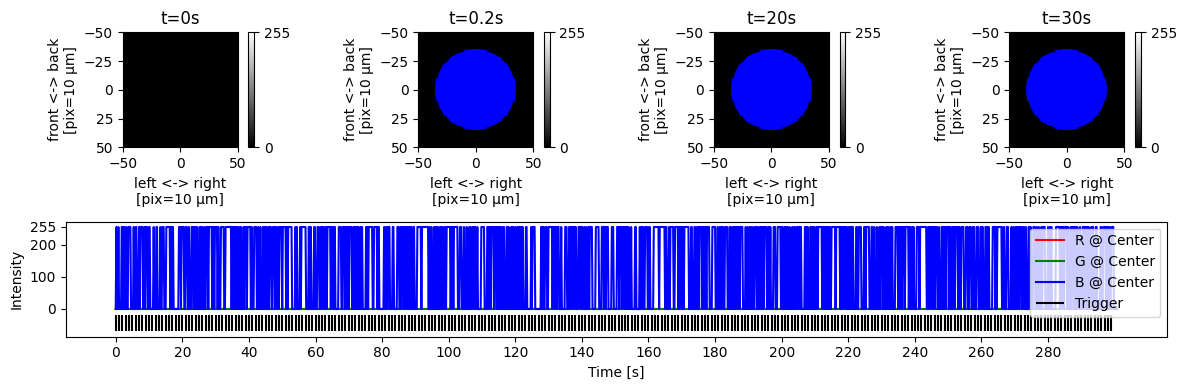

In [18]:
for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name}')
    fig, axs = plot_stim(stim, green_mark, time_stim, t_s_plot=t_s_plot);
    plt.savefig(os.path.join(out_dir, f'{name}.pdf'), bbox_inches='tight')
    plt.show()

In [19]:
assert np.isclose(target_freq, np.round(1 / np.mean(np.diff(time_stim))))

for (name, setup), stim in stim_dict.items():
    
    assert np.all(stim.astype(np.uint8) == stim)

    np.savez_compressed(
        os.path.join(out_dir, f'{name}_movie_and_trigger'),
        stimulus=stim.astype(np.uint8),
        framerate=target_freq,
        time=time_stim.astype(np.float32),
        trigger=green_mark,
        pixel_size_um=pixel_size_um,
    )